# **Generador de visualizaciones para resultados de tesis**

## **1. Paquetes**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Tic Tac Toe**

#### **Grafica 1: Q-learning Estandar vs LLM - Win Rate y Draw Rate**

> Comparación de modelos con aprendizaje tabular Q.

In [39]:
# CARGAR DATOS

# Estándar

ttt_q_std_acciones = pd.read_csv('../juegos/tictactoe/datos_output/acciones_tictactoe_qlearning_std_random_block_20251021_015440_episodes_10000.csv')
ttt_q_std_resumen = pd.read_csv('../juegos/tictactoe/datos_output/computo_tictactoe_qlearning_std_random_block_20251021_015440_episodes_10000.csv')
ttt_q_std_computo = pd.read_csv('../juegos/tictactoe/datos_output/resumen_tictactoe_qlearning_std_random_block_20251021_015440_episodes_10000.csv')
ttt_q_std_victorias = pd.read_csv('../juegos/tictactoe/datos_output/victorias_tictactoe_qlearning_std_random_block_20251021_015440_episodes_10000.csv')

# Estándar

ttt_q_llm_acciones = pd.read_csv('../juegos/tictactoe/datos_output/acciones_tictactoe_qlearning_groq_random_block_20251021_020328_episodes_10000.csv')
ttt_q_llm_resumen = pd.read_csv('../juegos/tictactoe/datos_output/computo_tictactoe_qlearning_groq_random_block_20251021_020328_episodes_10000.csv')
ttt_q_llm_computo = pd.read_csv('../juegos/tictactoe/datos_output/resumen_tictactoe_qlearning_groq_random_block_20251021_020328_episodes_10000.csv')
ttt_q_llm_victorias = pd.read_csv('../juegos/tictactoe/datos_output/victorias_tictactoe_qlearning_groq_random_block_20251021_020328_episodes_10000.csv')

In [15]:
ttt_q_std_victorias

,Epoch,Victorias,Empates,Derrotas,WinRate(%)
0,1.0,52.0,15.0,33.0,52.0
1,2.0,61.0,15.0,24.0,61.0
2,3.0,59.0,13.0,28.0,59.0
3,4.0,67.0,14.0,19.0,67.0
4,5.0,61.0,16.0,23.0,61.0
...,...,...,...,...,...
95,96.0,80.0,9.0,11.0,80.0
96,97.0,86.0,8.0,6.0,86.0
97,98.0,82.0,11.0,7.0,82.0
98,99.0,77.0,10.0,13.0,77.0


In [23]:
# Agregar label

ttt_q_std_victorias['Modelo'] = "Q-learning Std"
ttt_q_llm_victorias['Modelo'] = "Q-learning + LLM"

In [24]:
# Join
df_ttt_victorias = pd.concat([ttt_q_std_victorias, ttt_q_llm_victorias], ignore_index=True)

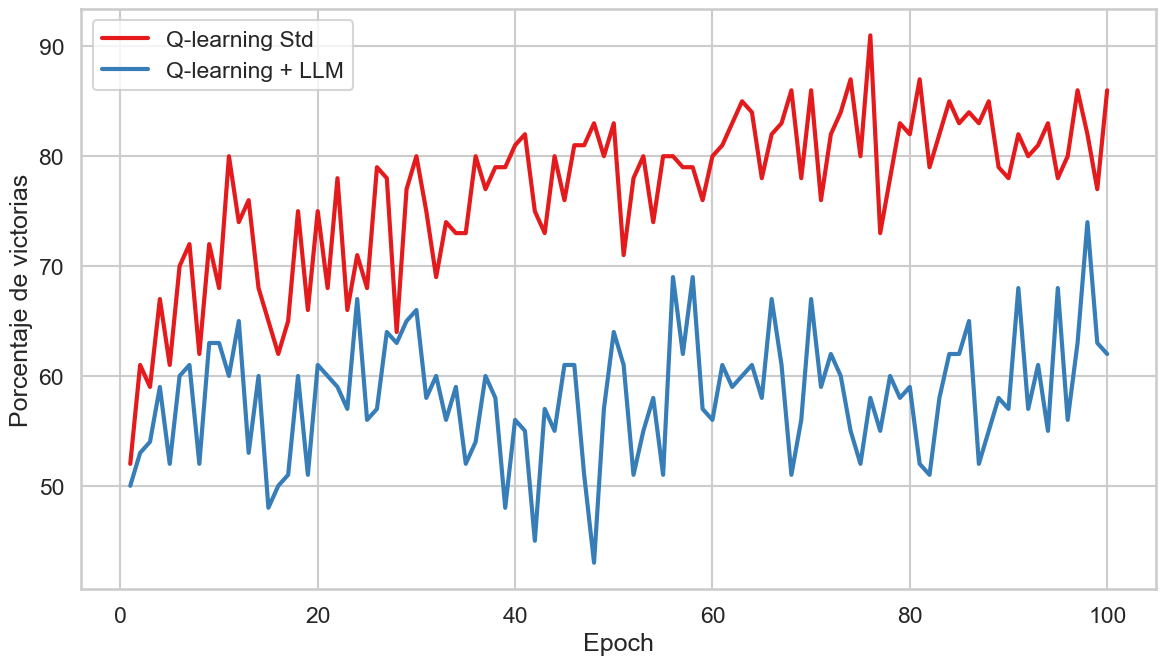

In [ ]:
# Gráficas

sns.set(style="whitegrid", context="talk")
palette = {
    "Q-learning Std": "#E41A1C",   # rojo R
    "Q-learning + LLM": "#377EB8"  # azul R
}

# Plot
plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_ttt_victorias,
    x="Epoch",
    y="WinRate(%)",
    hue="Modelo",
    palette=palette,
    linewidth=3
)

plt.title("")
plt.xlabel("Epoch")
plt.ylabel("Porcentaje de victorias")
plt.legend(title="")
plt.tight_layout()

# Guardar (alta calidad para tesis)
plt.savefig(
    "imagenes/g1_ttt_winrate_ql.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Grafica 2: Q-learning Estandar vs LLM - Draw Rate**

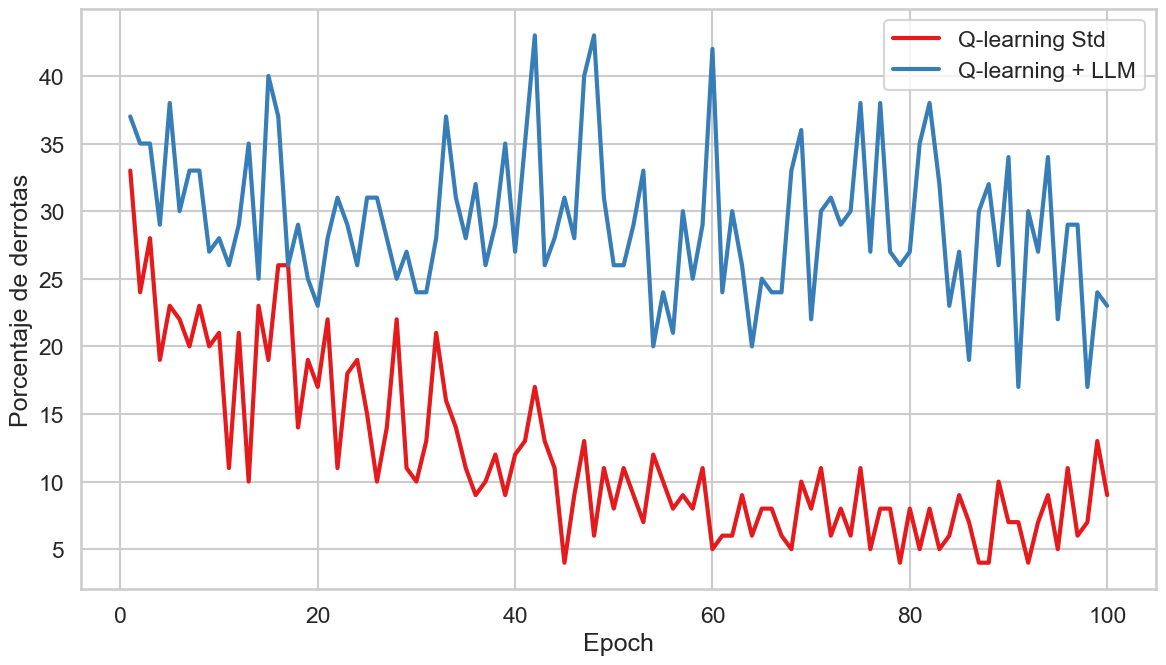

In [32]:
# Gráficas

sns.set(style="whitegrid", context="talk")
palette = {
    "Q-learning Std": "#E41A1C",   # rojo R
    "Q-learning + LLM": "#377EB8"  # azul R
}

# Plot
plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_ttt_victorias,
    x="Epoch",
    y="Derrotas",
    hue="Modelo",
    palette=palette,
    linewidth=3
)

plt.title("")
plt.xlabel("Epoch")
plt.ylabel("Porcentaje de derrotas")
plt.legend(title="")
plt.tight_layout()

# Guardar (alta calidad para tesis)
plt.savefig(
    "imagenes/g2_ttt_lossrate_ql.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Gráfica 3: Q-Learning Estándar vs LLM - Análisis de recompensas acumuladas**

In [40]:
# Agregar label

ttt_q_std_acciones['Modelo'] = "Q-learning Std"
ttt_q_llm_acciones['Modelo'] = "Q-learning + LLM"

In [49]:
# Agrupar data y unir

ttt_q_std_acciones_acum = (
    ttt_q_std_acciones
    .sort_values(["Epoch", "Episodio", "Modelo"])
    .groupby(["Epoch", "Episodio", "Modelo"], as_index=False)
    .tail(1)[["Epoch", "Episodio", "Modelo", "RewardAcum"]]
)

ttt_q_llm_acciones_acum = (
    ttt_q_llm_acciones
    .sort_values(["Epoch", "Episodio", "Modelo"])
    .groupby(["Epoch", "Episodio", "Modelo"], as_index=False)
    .tail(1)[["Epoch", "Episodio", "Modelo", "RewardAcum"]]
)

df_ttt_q_acciones_acum = pd.concat([ttt_q_std_acciones_acum, ttt_q_llm_acciones_acum], ignore_index=True)

In [53]:
# Calcular metrica por episodio

# Promedio por epoch
df_epoch_rewards = (
    df_ttt_q_acciones_acum
    .groupby(["Modelo", "Epoch"])["RewardAcum"]
    .agg(
        MeanRewardEpisode="mean",
        StdRewardEpisode="std"
    )
    .reset_index()
)

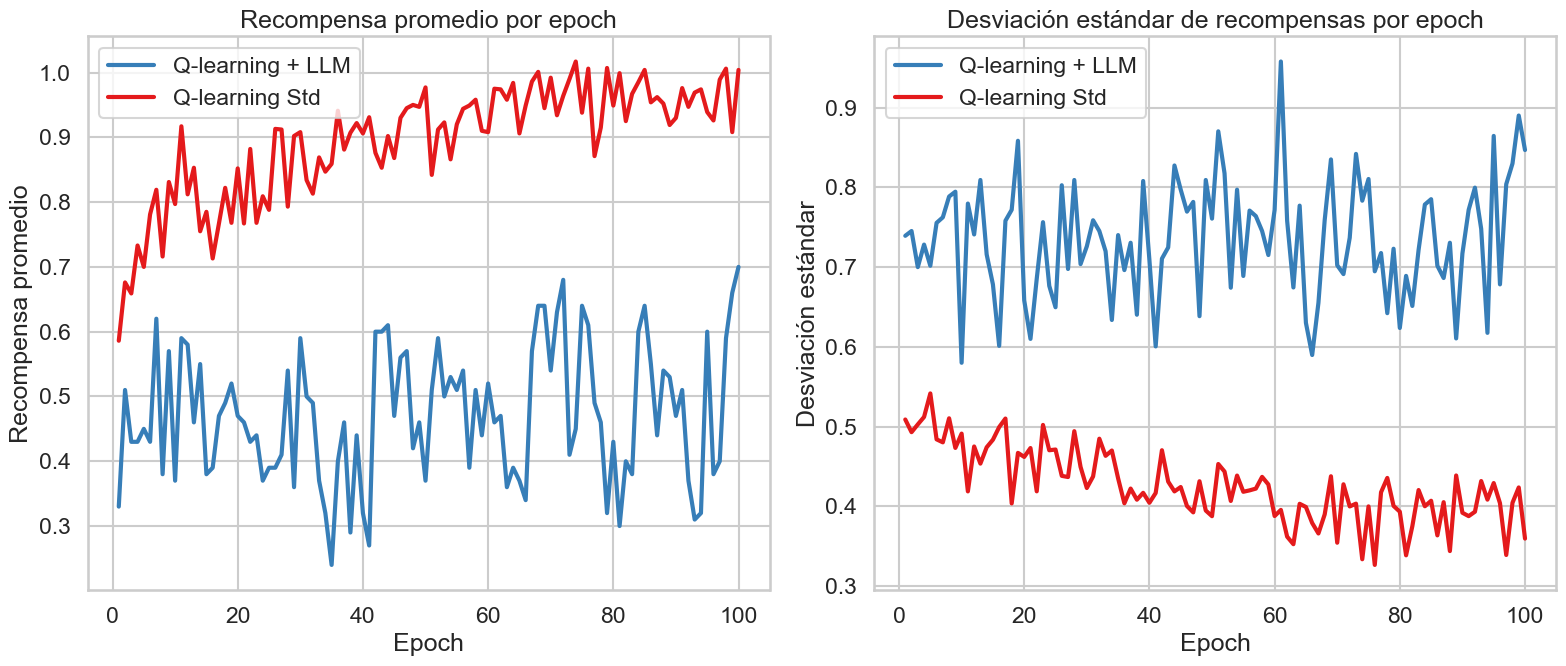

In [ ]:
sns.set(style="whitegrid", context="talk")

palette = {
    "Q-learning Std": "#E41A1C",
    "Q-learning + LLM": "#377EB8"
}

fig, axes = plt.subplots(1, 2, figsize=(16,7), sharex=True)

# ===== Promedio =====
sns.lineplot(
    data=df_epoch_rewards,
    x="Epoch",
    y="MeanRewardEpisode",
    hue="Modelo",
    palette=palette,
    linewidth=3,
    ax=axes[0]
)

axes[0].set_title("Recompensa promedio por epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Recompensa promedio")
axes[0].legend(title="")

# ===== Desv. estándar =====
sns.lineplot(
    data=df_epoch_rewards,
    x="Epoch",
    y="StdRewardEpisode",
    hue="Modelo",
    palette=palette,
    linewidth=3,
    ax=axes[1]
)

axes[1].set_title("Desviación estándar de recompensas por epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Desviación estándar")
axes[1].legend(title="")

plt.tight_layout()

# Guardar (alta calidad para tesis)
plt.savefig(
    "imagenes/g3_ttt_rewards_analysis_ql.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### **Gráfica 4: Heatmap de acciones**

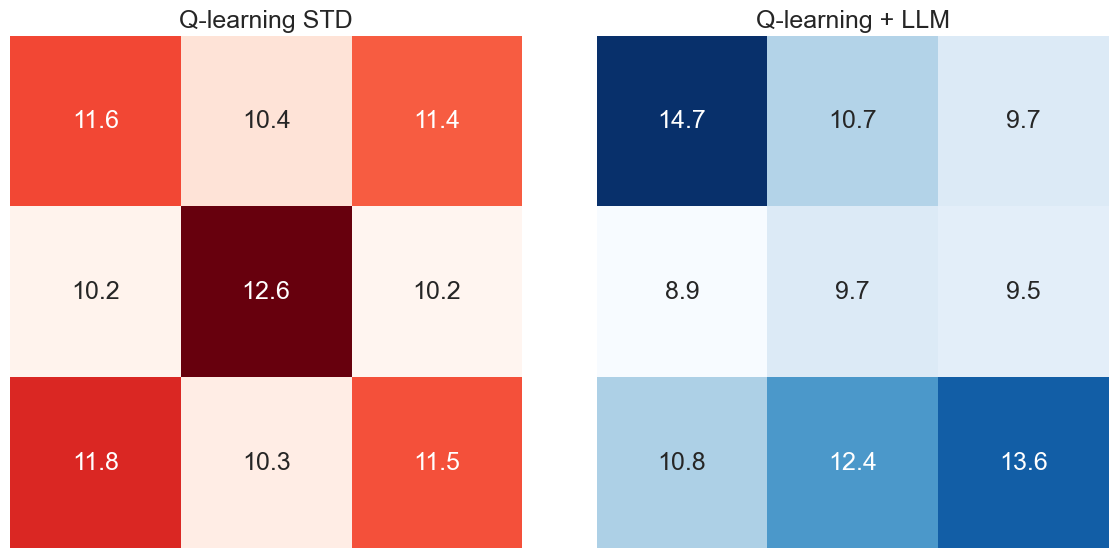

In [67]:
# Obtener porcentajes en vez de conteos
def action_grid_percent(df):
    probs = (
        df["Acción"]
        .value_counts(normalize=True)   # <- porcentaje
        .reindex(range(9), fill_value=0)
        * 100
    )
    return np.array(probs).reshape(3,3)

grid_std = action_grid_percent(ttt_q_std_acciones)
grid_llm = action_grid_percent(ttt_q_llm_acciones)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# STD
sns.heatmap(
    grid_std,
    annot=True,
    fmt=".1f",      # 1 decimal
    cmap="Reds",
    cbar=False,
    square=True,
    ax=axes[0]
)
axes[0].set_title("Q-learning STD")
axes[0].set_xticks([])
axes[0].set_yticks([])

# LLM
sns.heatmap(
    grid_llm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar=False,
    square=True,
    ax=axes[1]
)
axes[1].set_title("Q-learning + LLM")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    "imagenes/g4_ttt_action_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## **3. Frozen Lake**

#### **Grafica 5: Q-learning vs DeepQN - Frozen Lake**

In [79]:
# CARGAR DATOS

# Estándar

fl_ql_std_winrate = pd.read_csv('../juegos/frozen_lake/datos_output/victorias_frozenlake_qlearning_std_fixedmap_size4_noslip_20251021_052005_episodes_10000.csv')
fl_deepqn_std_winrate = pd.read_csv('../juegos/frozen_lake/datos_output/victorias_frozenlake_dqn_per_episode_random_size4_noslip_20251021_065345_episodes_10000.csv')

In [80]:
# Label de modelos
fl_ql_std_winrate["Modelo"] = "Q-Learning"
fl_deepqn_std_winrate["Modelo"] = "Deep QN"


# Join
df_fl_stdvs = pd.concat([fl_ql_std_winrate, fl_deepqn_std_winrate], ignore_index=True)

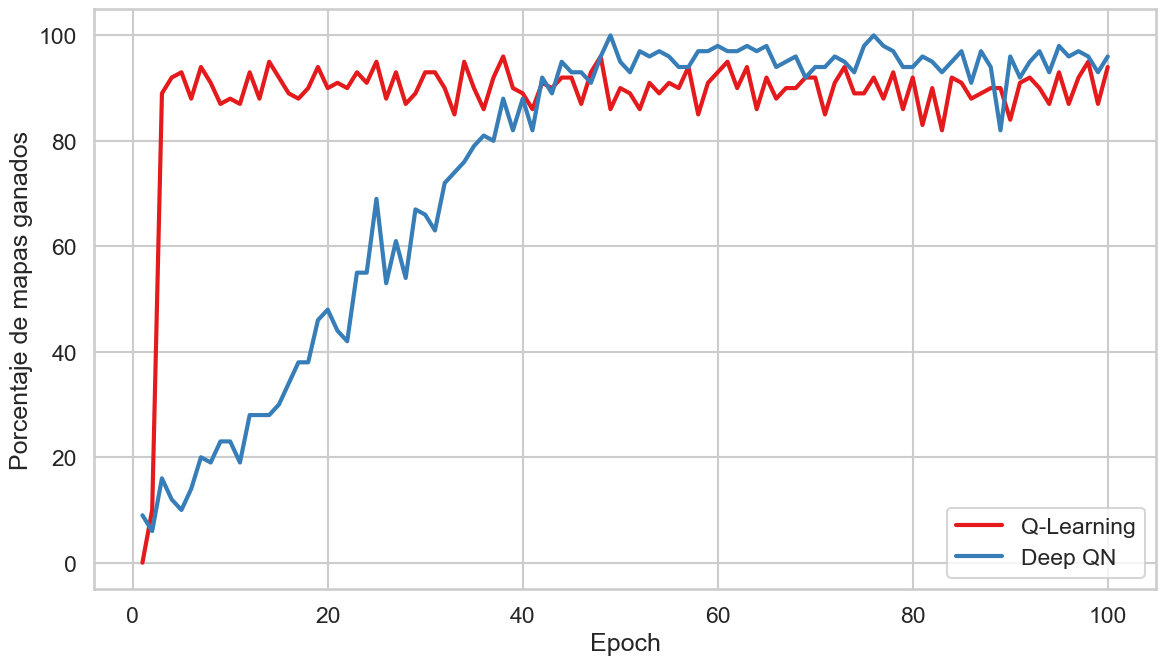

In [84]:
# Gráficas

sns.set(style="whitegrid", context="talk")
palette = {
    "Q-Learning": "#E41A1C",   # rojo R
    "Deep QN": "#377EB8"  # azul R
}

# Plot
plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_fl_stdvs,
    x="Epoch",
    y="Exitos",
    hue="Modelo",
    palette=palette,
    linewidth=3
)

plt.title("")
plt.xlabel("Epoch")
plt.ylabel("Porcentaje de mapas ganados")
plt.legend(title="")
plt.tight_layout()

# Guardar (alta calidad para tesis)
plt.savefig(
    "imagenes/g5_deepqn_vs_ql.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

! ✅ WinRate: 35.50% | episodios=200 | tiempo=0.05s para resultados de tabla Q


! ✅ WinRate: 35.50% | episodios=200 | tiempo=0.05s para resultados de tabla Q
! ✅ WinRate: 88.50% | episodios=200 | tiempo=0.79s

#### **Grafica 6: Q-Learning vs DeepQN vs LLM Replica**

In [85]:
# CARGAR DATOS

# Estándar

fl_ql_deepqn_llm_replicate_winrate = pd.read_csv('../juegos/frozen_lake/datos_output/victorias_frozenlake_dqn_llm_episodic_preferences_basic_finishornot_per_episode_random_size4_noslip_20260125_173740_episodes_5000.csv')

In [86]:
# Label de modelos
fl_ql_deepqn_llm_replicate_winrate["Modelo"] = "Deep QN LLM Replicate function"


# Join
df_fl_stdvs_2 = pd.concat([fl_ql_std_winrate, fl_deepqn_std_winrate, fl_ql_deepqn_llm_replicate_winrate], ignore_index=True)

In [87]:
df_fl_stdvs_2

,Epoch,Exitos,Fracasos,WinRate(%),Modelo
0,1.0,0.0,100.0,0.0,Q-Learning
1,2.0,10.0,90.0,10.0,Q-Learning
2,3.0,89.0,11.0,89.0,Q-Learning
3,4.0,92.0,8.0,92.0,Q-Learning
4,5.0,93.0,7.0,93.0,Q-Learning
...,...,...,...,...,...
245,46.0,86.0,13.0,86.0,Deep QN LLM Replicate function
246,47.0,92.0,8.0,92.0,Deep QN LLM Replicate function
247,48.0,90.0,8.0,90.0,Deep QN LLM Replicate function
248,49.0,95.0,4.0,95.0,Deep QN LLM Replicate function


### **3.2 Compara modelo base vs estándar**

### **3.3 Comparación de directivas avanzadas**